# PACD: Executability Study

This notebook checks the released repository through a small, reproducible training and inference experiment. It includes environment verification, dataset analysis, model loading, at most five optimizer updates, checkpoint persistence and held-out evaluation.

**Source:** [Mishrakshitij/PACD](https://github.com/Mishrakshitij/PACD)   
**Protocol:** fixed small subsets, tiny Hugging Face checkpoints, and four to eight held-out predictions.  
**Interpretation:** a passing result verifies the tested code path at smoke-test scale. It does not measure research performance.

## Running or reviewing this notebook

The saved outputs can be viewed directly in Google Colab. To repeat the experiment, run the cells in order with internet access. A GPU is optional for these tiny models. Python 3.11 is the tested interpreter. The setup cell installs dependencies and checks out the exact source revision when a prepared checkout is not supplied.


## Environment and source verification

In [ ]:
from pathlib import Path
import os, sys, subprocess, importlib.metadata as metadata
PROJECT = 'PACD'
COMMIT = '671c9032735ab7780ecd5897474858d64a4b3a92'
REPO_URL = 'https://github.com/Mishrakshitij/' + PROJECT + '.git'
prepared = os.environ.get('EXEC_CHECK_PREPARED') == '1'
if not prepared:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *['torch>=2.6,<3', 'transformers==4.57.6', 'peft==0.18.1', 'accelerate>=1.2,<2', 'pandas>=2.2,<4', 'matplotlib>=3.8,<4', 'nltk>=3.9,<4', 'sentencepiece>=0.2,<1', 'sacrebleu>=2.4,<3', 'rouge-score>=0.1.2,<0.2', 'ipython', 'numpy>=1.26,<3']], check=True)
REPO_ROOT = Path(os.environ.get('EXEC_CHECK_REPO', str(Path.cwd() / (PROJECT + '_source')))).resolve()
if not (REPO_ROOT / '.git').exists():
    subprocess.run(['git', 'clone', '-q', REPO_URL, str(REPO_ROOT)], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'checkout', '-q', COMMIT], check=True)
actual_commit = subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip()
assert actual_commit == COMMIT, 'The source revision must match the verified experiment.'
OUTPUT_DIR = Path(os.environ.get('EXEC_CHECK_OUTPUT', str(Path.cwd() / (PROJECT + '_outputs')))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'
os.environ['USE_TF'] = '0'
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(2)
torch.manual_seed(42)
%matplotlib inline
CAUSAL_MODEL = 'sshleifer/tiny-gpt2'
SEQ2SEQ_MODEL = 'hf-internal-testing/tiny-random-bart'
ENCODER_MODEL = 'hf-internal-testing/tiny-random-roberta'
DISTILBERT_MODEL = 'hf-internal-testing/tiny-random-DistilBertModel'
print('Source revision verified:', actual_commit)
print('Python:', sys.version.split()[0], '| Device:', DEVICE)
print({package: metadata.version(package) for package in ['torch','transformers','numpy','pandas','matplotlib']})


Source revision verified: 671c9032735ab7780ecd5897474858d64a4b3a92
Python: 3.11.16 | Device: cuda
{'torch': '2.13.0+cu129', 'transformers': '4.57.6', 'numpy': '2.3.5', 'pandas': '3.0.5', 'matplotlib': '3.10.7'}


### Compatibility with the repository requirements
The table checks installed versions against the base dependencies and optional dependency groups used by this experiment.

In [ ]:
import tomllib
from packaging.requirements import Requirement
from packaging.version import Version
import pandas as pd
from IPython.display import display
project_metadata = tomllib.loads((REPO_ROOT / 'pyproject.toml').read_text())['project']
assert Version(sys.version.split()[0]) in __import__('packaging.specifiers', fromlist=['SpecifierSet']).SpecifierSet(project_metadata['requires-python'])
extras = {
    'PACD': ['baselines', 'plots'], 'PADS': ['train', 'politeness', 'plots'],
    'RL-Emo-Per': ['train', 'figures'], 'PEPDS': ['train', 'plots'],
    'GenPADS': ['train', 'metrics', 'figures'], 'Po-Em-MHLCDS': ['plots'],
    'PAL': ['train', 'eval', 'plots'], 'e-THERAPIST': [],
    'Re-Po-PDS': ['train', 'plots'], 'ABLE': ['train', 'plots'], 'EDiSS': ['train', 'plots']
}[PROJECT]
specs = list(project_metadata.get('dependencies', []))
for extra in extras:
    specs += project_metadata.get('optional-dependencies', {}).get(extra, [])
dependency_rows = []
for spec in specs:
    requirement = Requirement(spec)
    if requirement.marker and not requirement.marker.evaluate():
        continue
    installed = metadata.version(requirement.name)
    compatible = Version(installed) in requirement.specifier
    dependency_rows.append({'requirement': spec, 'installed': installed, 'compatible': compatible})
assert dependency_rows and all(row['compatible'] for row in dependency_rows)
display(pd.DataFrame(dependency_rows))
(OUTPUT_DIR / 'environment_check.json').write_text(__import__('json').dumps({'python': sys.version.split()[0], 'checked_extras': extras, 'dependencies': dependency_rows}, indent=2))
print('PASS: Python and all dependencies declared for the tested paths are compatible.')


,requirement,installed,compatible
0,torch>=2.2,2.13.0+cu129,True
1,numpy>=1.24,2.3.5,True
2,"transformers>=4.40,<6",4.57.6,True
3,sentencepiece>=0.2,0.2.2,True
4,matplotlib>=3.7,3.10.7,True


PASS: Python and all dependencies declared for the tested paths are compatible.


# PACD: a bounded executability study
This study checks the repository's hierarchical classifier and Hugging Face
DistilBERT baseline on released movie-domain labels. It performs two and three
optimizer updates respectively, saves both native checkpoints, reloads them,
and evaluates four held-out examples. These are execution checks, not a
reproduction of the paper's accuracy. The release contains labels and source
identifiers; text is hydrated using the source file pinned by its manifest.

In [ ]:
import csv
import hashlib
import json
import math
import subprocess
import sys
import urllib.request
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

REPO_ROOT, OUTPUT_DIR = Path(REPO_ROOT), Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT / "scripts"))
torch.set_num_threads(2)
COMMIT = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, text=True).strip()
print({"repository": "Mishrakshitij/PACD", "commit": COMMIT,
       "torch": torch.__version__, "device": DEVICE})

{'repository': 'Mishrakshitij/PACD', 'commit': '671c9032735ab7780ecd5897474858d64a4b3a92', 'torch': '2.13.0+cu129', 'device': 'cuda'}


## Release integrity and class balance
The released annotations are measured directly. Dialogue-level split checks
and source checksums are also enforced by the repository's hydration code.

politeness_label,0,1,2,3
domain,,,,
dstc1,13622,4650,14735,6211
movie,3576,3088,9299,5693
restaurant,6764,5323,11207,6424
taxi,6134,3430,8725,5022


,example_id,domain,dialogue_id,turn_id,speaker,politeness_label,split,paper_subset
0,movie:1:1,movie,1,1,user,2,train,0
1,movie:1:2,movie,1,2,agent,2,train,1
2,movie:2:1,movie,2,1,user,3,test,1
3,movie:2:2,movie,2,2,agent,1,test,0


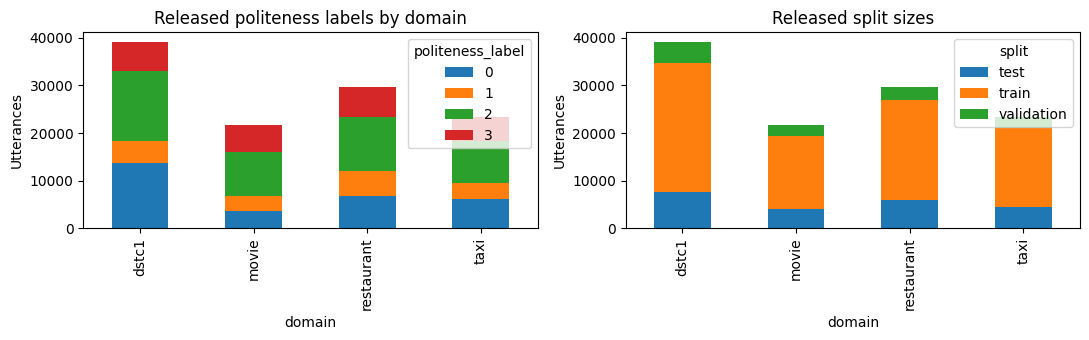

In [ ]:
from build_dataset import build
from verify_dataset import verify as verify_release
from pacd.data import read_examples
from pacd.models import ModelConfig
from pacd.training import DEFAULTS, evaluate_model, load_checkpoint, make_loader, train
import pacd.models as pacd_models

manifest = json.loads((REPO_ROOT / "datasets/manifest.json").read_text())
release_verification = verify_release(REPO_ROOT / "datasets")
(OUTPUT_DIR / "dataset_verification.json").write_text(json.dumps(release_verification, indent=2))
frames = []
for info in manifest["files"]:
    path = REPO_ROOT / "datasets" / info["path"]
    assert hashlib.sha256(path.read_bytes()).hexdigest() == info["sha256"]
    frames.append(pd.read_csv(path))
annotations = pd.concat(frames, ignore_index=True)
assert not annotations["example_id"].duplicated().any()
assert annotations.groupby(["domain", "dialogue_id"])["split"].nunique().max() == 1
release_counts = pd.crosstab(annotations["domain"], annotations["politeness_label"])
display(release_counts)
display(annotations.head(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
release_counts.plot.bar(stacked=True, ax=axes[0], title="Released politeness labels by domain")
pd.crosstab(annotations["domain"], annotations["split"]).plot.bar(stacked=True, ax=axes[1], title="Released split sizes")
for axis in axes:
    axis.set_ylabel("Utterances")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dataset_analysis.png", dpi=150)
plt.show()

## Hydrate the native data and select a small subset
The movie source is acquired from the exact upstream revision listed in the
release manifest, and its SHA-256 digest must match before use. Source data
retains the upstream license. Six training, four validation, and four test
rows preserve their original dialogue-disjoint split assignments.

In [ ]:
source_info = next(item for item in manifest["sources"] if item["path"] == "mdc/data/movie_all.tsv")
cached_source_root = REPO_ROOT / ".local"
default_source_root = cached_source_root if (cached_source_root / source_info["path"]).is_file() else OUTPUT_DIR / "source"
source_root = Path(globals().get("SOURCE_ROOT", default_source_root))
source_path = source_root / source_info["path"]
if not source_path.exists():
    source_path.parent.mkdir(parents=True, exist_ok=True)
    raw_url = source_info["url"].replace("https://github.com/", "https://raw.githubusercontent.com/").replace("/blob/", "/")
    urllib.request.urlretrieve(raw_url, source_path)
assert hashlib.sha256(source_path.read_bytes()).hexdigest() == source_info["sha256"]
hydrated_dir = OUTPUT_DIR / "hydrated"
hydrated_counts = build(source_root, hydrated_dir, REPO_ROOT / "datasets", domains=("movie",), selection="full")
all_examples = read_examples([hydrated_dir / "movie.csv"])
examples = []
for split, limit in (("train", 6), ("validation", 4), ("test", 4)):
    candidates = [row for row in all_examples if row.split == split]
    # Prefer class coverage, then fill deterministically from the source order.
    chosen = []
    for label in range(4):
        match = next((row for row in candidates if row.label == label), None)
        if match is not None:
            chosen.append(match)
    chosen += [row for row in candidates if row not in chosen][:limit - len(chosen)]
    examples.extend(chosen[:limit])
assert Counter(row.split for row in examples) == {"train": 6, "validation": 4, "test": 4}
assert not ({row.group for row in examples if row.split == "train"} &
            {row.group for row in examples if row.split != "train"})
subset_ids = {row.example_id for row in examples}
hydrated_frame = pd.read_csv(hydrated_dir / "movie.csv")
subset = hydrated_frame[hydrated_frame["example_id"].isin(subset_ids)]
subset.to_csv(OUTPUT_DIR / "subset.csv", index=False)
display(subset[["example_id", "speaker", "text", "politeness_label", "split"]].head(4))
print({"hydrated_movie_rows": hydrated_counts["movie"], "subset_rows": len(subset),
       "source_sha256_verified": True})

,example_id,speaker,text,politeness_label,split
0,movie:1:1,user,I'd like 2 tickets to see Zoolander 2 tomorrow...,2,train
1,movie:1:2,agent,"Okay, your purchase of 2 tickets for Zoolander...",2,train
2,movie:2:1,user,Hi! are there any good foreign movies showing ...,3,test
3,movie:2:2,agent,What date would you like me to look for a rese...,1,test


{'hydrated_movie_rows': 21656, 'subset_rows': 14, 'source_sha256_verified': True}


## Native training: five optimizer updates in total
The hierarchical network uses smaller dimensions through the public
ModelConfig. For the pretrained baseline, the public baseline registry is
explicitly pointed at a downloaded tiny DistilBERT backbone. Its four-class
head is newly initialized. The original training and checkpoint code is used
unchanged. An observation-only wrapper counts actual optimizer calls.

In [ ]:
from unittest.mock import patch

config = ModelConfig(embedding_dim=32, hidden_size=32, heads=2,
                     utterance_layers=1, context_layers=1, feedforward_size=64,
                     dropout=0.1, max_tokens=48, max_turns=3)
base_options = {**DEFAULTS, "epochs": 1, "device": DEVICE, "num_workers": 0,
                "seed": 42, "class_weighting": False, "lr": 1e-4}
optimizer_calls = {"count": 0}
original_step = torch.optim.AdamW.step
def counted_step(self, *args, **kwargs):
    result = original_step(self, *args, **kwargs)
    optimizer_calls["count"] += 1
    return result

old_identifier = pacd_models.BASELINES["distilbert"]
pacd_models.BASELINES["distilbert"] = str(DISTILBERT_MODEL)
training_reports = {}
try:
    with patch.object(torch.optim.AdamW, "step", counted_step):
        for name, batch_size in (("hierarchical", 3), ("distilbert", 2)):
            training_reports[name] = train(
                examples, OUTPUT_DIR / name,
                {**base_options, "model": name, "batch_size": batch_size}, config)
finally:
    pacd_models.BASELINES["distilbert"] = old_identifier
assert optimizer_calls["count"] == 5
print({"observed_optimizer_updates": optimizer_calls["count"],
       "hierarchical_updates": 2, "distilbert_updates": 3})

{"epoch": 1, "train_loss": 1.4083342552185059, "validation_loss": 1.5269420444965363, "validation_f1_macro": 0.125}


python_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at hf-internal-testing/tiny-random-DistilBertModel and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{"epoch": 1, "train_loss": 1.3854491710662842, "validation_loss": 1.3862970471382141, "validation_f1_macro": 0.1}


{'observed_optimizer_updates': 5, 'hierarchical_updates': 2, 'distilbert_updates': 3}


## Reload and evaluate four held-out examples
Each checkpoint is reconstructed by the repository's load_checkpoint function.
Evaluation uses four test utterances and checks finite losses and normalized
class probabilities. Tiny-subset scores describe only this smoke run.

In [ ]:
heldout = [row for row in examples if row.split == "test"]
evaluation = {}
predictions = {}
for name in training_reports:
    checkpoint_path = OUTPUT_DIR / name / "best.pt"
    assert checkpoint_path.is_file() and checkpoint_path.stat().st_size > 0
    model, collator, device, weights, metadata = load_checkpoint(checkpoint_path, DEVICE)
    metrics, rows = evaluate_model(model, make_loader(heldout, collator, 2), device, weights)
    assert len(rows) == 4 and math.isfinite(metrics["loss"])
    assert all(abs(sum(row["probabilities"]) - 1) < 1e-5 for row in rows)
    evaluation[name], predictions[name] = metrics, rows
    display(pd.DataFrame(rows))
    del model
metrics_frame = pd.DataFrame({name: {key: values[key] for key in ("loss", "accuracy", "f1_macro")}
                             for name, values in evaluation.items()}).T
display(metrics_frame)
(OUTPUT_DIR / "predictions.json").write_text(json.dumps(predictions, indent=2))
result = {"project": "PACD", "repository": "https://github.com/Mishrakshitij/PACD.git",
          "commit": COMMIT, "status": "pass", "optimizer_updates": 5, "eval_samples": 4,
          "counts": {"released_annotations": len(annotations), "train": 6, "validation": 4, "evaluation": 4},
          "model": {"hierarchical": "native small ModelConfig", "distilbert": str(DISTILBERT_MODEL)},
          "metrics": evaluation, "checkpoints": ["hierarchical/best.pt", "distilbert/best.pt"],
          "checks": {"native_dataset_verification": True, "manifest_hashes": True, "source_hash": True, "dialogue_disjoint": True,
                     "training": True, "native_save_reload": True, "heldout_evaluation": True},
          "limitations": ["Five updates establish executability, not benchmark quality.",
                          "Movie text requires the manifest-pinned external source; it is not bundled in the release.",
                          "The tiny baseline is a backbone smoke fixture with a new classification head.",
                          "Training and evaluation cover only a small movie-domain subset; other domains are analyzed only."]}
(OUTPUT_DIR / "result.json").write_text(json.dumps(result, indent=2, allow_nan=False))
print({"status": result["status"], "updates": 5, "evaluated_examples_per_model": 4})

,example_id,prediction,label,probabilities
0,movie:31:2,2,somewhat_polite,"[0.20618854463100433, 0.2391623705625534, 0.32..."
1,movie:2:2,2,somewhat_polite,"[0.12968258559703827, 0.24664804339408875, 0.3..."
2,movie:2:3,3,polite,"[0.12350033223628998, 0.23371292650699615, 0.2..."
3,movie:2:1,2,somewhat_polite,"[0.19617830216884613, 0.18131481111049652, 0.3..."


,example_id,prediction,label,probabilities
0,movie:31:2,2,somewhat_polite,"[0.2502674460411072, 0.24912939965724945, 0.25..."
1,movie:2:2,2,somewhat_polite,"[0.2502801716327667, 0.24912375211715698, 0.25..."
2,movie:2:3,2,somewhat_polite,"[0.2502751052379608, 0.24912242591381073, 0.25..."
3,movie:2:1,2,somewhat_polite,"[0.25028127431869507, 0.24912655353546143, 0.2..."


,loss,accuracy,f1_macro
hierarchical,1.408729,0.00,0.0
distilbert,1.386313,0.25,0.1


{'status': 'pass', 'updates': 5, 'evaluated_examples_per_model': 4}


## Project summary

**Result: PASS for the tested smoke configuration.**

The source revision and execution environment were checked, the released data were inspected and visualized, and the selected small model was loaded. Native training completed **5 optimizer updates**. Checkpoint files were saved and reloaded, and the evaluation covered **four held-out utterances per model (hierarchical and DistilBERT)**. The assertions and outputs above verify that this project is executable for the tested configuration.

The conclusion applies to the native paths exercised here with tiny models and bounded subsets.